# HW2: Policy Gradiant
> - Full Name: **Amirhosein Rezaei**
> - Student ID: **401105989**


## Objective

In this notebook, you will implement the **REINFORCE policy gradient algorithm** (also known as Monte Carlo policy gradient) to train an agent on the **CartPole‑v1** environment from OpenAI Gym. REINFORCE is a fundamental policy‑based reinforcement learning method that directly optimises the policy parameters by performing stochastic gradient ascent on the expected cumulative reward. However, the standard REINFORCE update is known to suffer from **high variance**, which can lead to slow convergence and unstable learning curves.

## Variance Reduction Techniques

To address this issue, this notebook further explores three variance‑reduction strategies that are commonly applied to the REINFORCE algorithm. You will implement each of them and empirically analyse their effects on learning speed, stability, and final performance. The techniques are:

1. **The causality trick (reward‑to‑go)**  
   Instead of using the full return from the start of an episode, this method replaces the cumulative reward with the sum of future rewards from each time step onward. By ignoring rewards obtained before the current action, the gradient estimator retains the same unbiasedness while significantly reducing variance.

2. **Constant baseline**  
   A fixed scalar baseline is subtracted from the return (or the reward‑to‑go) in the policy gradient estimate. Subtracting a constant does not introduce bias, but a well‑chosen constant (e.g., the average return over recent episodes) can reduce variance by centring the advantage estimates.

3. **Learned baseline (value function baseline)**  
   A more sophisticated approach that uses a separate function approximator (typically a neural network) to estimate the state‑value function. This learned baseline adapts during training and provides a state‑dependent offset. The advantage estimate then often yields the lowest variance among these three methods, at the cost of adding a second learning process.

## Implementation and Analysis

You will implement the core REINFORCE update, then systematically extend it with each of the three variance‑reduction techniques. For every variant, you will run multiple training episodes, plot the smoothed episode returns, and compare convergence behaviour. The notebook will guide you through:

- Setting up the CartPole‑v1 environment (discrete action space, continuous observation space).
- Defining a policy network (e.g., a shallow multi‑layer perceptron) with a softmax output layer.
- Writing the training loop that collects episodes, computes policy gradients, and updates the policy.
- Modifying the advantage estimator to incorporate causality and baseline subtractions.
- Training and evaluating each variant with identical random seeds for fair comparison.

By the end of this notebook, you will gain hands‑on insight into how different variance‑reduction mechanisms affect the practical performance of Monte Carlo policy gradient methods.

# Setup

All required packages are pre-installed if using Google Colab.


Import the following libraries.

In [1]:
# Imports
import numpy as np
if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import gym
import matplotlib
import matplotlib.pyplot as plt
import base64
import imageio
import IPython
import logging
import warnings
import random

# Disable warnings
logging.getLogger().setLevel(logging.ERROR)
warnings.filterwarnings('ignore', category=DeprecationWarning)

# DEVICE
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


device(type='cuda')

Note: While we check for CUDA availability, using a GPU is not strictly necessary for this assignment. The neural networks used here are small, and the majority of training time is spent running episodes in the environment (which occurs on the CPU), rather than performing backpropagation updates.

Set a fix seed to be able to compare results

In [2]:
def set_seed(seed=333):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(333)

Configure Matplotlib for Interactive and XKCD-Style Plots

In [3]:
# Set up matplotlib
is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython:
    from IPython import display
plt.ion()
plt.xkcd(scale=1, length=100, randomness=2)
matplotlib.rcParams['figure.figsize'] = (12, 6)

Record and Embed Simulation Videos in Jupyter Notebook

<b>embed_mp4:</b> Converts an MP4 video into a base64-encoded HTML tag for display in Jupyter Notebook.
<br>
<b>record_simulation:</b> Runs a policy in the environment, records the simulation, and saves it as an MP4 video.

In [40]:
def embed_mp4(filename):
    video = open(filename,'rb').read()
    b64 = base64.b64encode(video)
    tag = '''
    <video width="640" height="480" controls>
    <source src="data:video/mp4;base64,{0}" type="video/mp4">
    Your browser does not support the video tag.
    </video>'''.format(b64.decode())
    return IPython.display.HTML(tag)

def record_simulation(env, policy_net, filename, episodes=1, fps=30):
    filename = filename + ".mp4"
    with imageio.get_writer(filename, fps=fps) as video:
        for _ in range(episodes):
            state, _ = env.reset()
            frame = env.render()  # Capture the first frame
            video.append_data(frame)

            done = False
            while not done:
                state_tensor = torch.FloatTensor(state).to(DEVICE)
                action = torch.argmax(policy_net(state_tensor)).item()
                state, _, terminated, truncated, _ = env.step(action)

                frame = env.render()  # Capture the frame after taking the action
                video.append_data(frame)

                done = terminated or truncated
    return embed_mp4(filename)

# Explore the environment

Initialize CartPole Environment and Display State & Action Spaces

In [41]:
# Create the CartPole environment
env = gym.make("CartPole-v1")

# Print observation and action space
print("Observation Space:", env.observation_space)
print("Action Space:", env.action_space)

Observation Space: Box([-4.8000002e+00 -3.4028235e+38 -4.1887903e-01 -3.4028235e+38], [4.8000002e+00 3.4028235e+38 4.1887903e-01 3.4028235e+38], (4,), float32)
Action Space: Discrete(2)


**Question**

How are the observation and action spaces defined in the CartPole environment?

**Answer:**

Observation Space: Box(4,) - Continuous values representing:

Cart position

Cart velocity

Pole angle

Pole angular velocity

Action Space: Discrete(2) - Two discrete actions:

0: Push cart left

1: Push cart right


Define a Random Policy for Action Selection  

In [42]:
class RandomPolicy(object):

    def __init__(self, action_space_n):
        self.action_space_n = action_space_n

    def __call__(self, state):
        action_values = torch.rand(self.action_space_n)
        return action_values

Visualize the random policy.

In [43]:
import numpy as np

random_policy = RandomPolicy(env.action_space.n)

record_simulation(gym.make("CartPole-v1", render_mode='rgb_array'), random_policy, "Video_CartPole_random_policy")

# Agent with REINFORCE: Normal vs Causality vs Simple Baseline vs Learned Baseline


### Policy Network Definition

To define a neural network that represents the agent’s policy for selecting actions.

The policy network takes the environment’s state as input and outputs a probability distribution over possible actions.

In [22]:
# Policy Network Definition
class PolicyNetwork(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(PolicyNetwork, self).__init__()
        # Implement a simple MLP policy
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, output_dim)
        self.dropout = nn.Dropout(p=0.1)

    def forward(self, state):
        # Return a probability distribution over actions
        x = torch.relu(self.fc1(state))
        x = torch.relu(self.fc2(x))
        x = self.dropout(x)
        logits = self.fc3(x)
        return torch.softmax(logits, dim=-1)

### REINFORCE without Causality

#### 1. The Objective Function
In Policy Gradient methods, we aim to maximize the expected return:
$$J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta} [G(\tau)]$$
where $\tau = (s_0, a_0, s_1, a_1, \dots, s_T)$ is a trajectory sampled from the policy $\pi_\theta$, and $G(\tau)$ is the total discounted return.

#### 2. The Policy Gradient Theorem
The gradient of the objective function is given by:
$$\nabla_\theta J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta} \left[ \left( \sum_{t=0}^{T} \nabla_\theta \log \pi_\theta(a_t | s_t) \right) G(\tau) \right]$$

#### 3. Full Return vs. Reward-to-go
In the code implementation `reinforce_no_causality`, we use the **Full Return** $G_0$ for every action in the trajectory:
- **Definition of $G_0$**: $G_0 = \sum_{k=0}^{T} \gamma^k R_k$
- **Update Rule**: $\theta \leftarrow \theta + \alpha \sum_{t=0}^{T} \nabla_\theta \log \pi_\theta(a_t | s_t) G_0$

#### Definitions:
- **$\pi_\theta(a_t | s_t)$**: The probability of taking action $a_t$ given state $s_t$ under parameters $\theta$.
- **$\nabla_\theta \log \pi_\theta(a_t | s_t)$**: The 'score function' or direction in parameter space that increases the probability of action $a_t$.
- **$G_0$**: The total scalar reward of the entire episode. If the episode was good, $G_0$ is high, and we push the probabilities of *all* actions taken in that episode 'up' equally.


In [18]:
# Implement REINFORCE without causality (using Full Return G_0)
def reinforce_no_causality(env, policy_net, optimizer, num_episodes=1000, gamma=0.99):
    rewards_per_episode = []
    for episode in range(num_episodes):
        # 1. Collect trajectory
        states = []
        actions = []
        rewards = []
        
        state, _ = env.reset()

        done = False
        
        while not done:
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
            
            action_probs = policy_net(state_tensor)
            dist = Categorical(action_probs)
            action = dist.sample()
            
            states.append(state)
            actions.append(action.item())
            
            next_state, reward, terminated, truncated, _ = env.step(action.item())
            done = terminated or truncated
            
            rewards.append(reward)
            state = next_state
        # 2. Compute G_0 (total discounted return)
        G_0 = 0
        for t, reward in enumerate(rewards):
            G_0 += (gamma ** t) * reward
        
        returns = [G_0] * len(rewards)
        # 3. Update policy
        optimizer.zero_grad()
        
        loss = 0
        for t in range(len(actions)):
            state_tensor = torch.FloatTensor(states[t]).unsqueeze(0).to(DEVICE)
            action_probs = policy_net(state_tensor)
            dist = Categorical(action_probs)
            
            log_prob = dist.log_prob(torch.tensor(actions[t]).to(DEVICE))
            loss += -log_prob * returns[t]
        
        loss = loss / len(actions)
        loss.backward()
        optimizer.step()
        
        total_reward = sum(rewards)
        rewards_per_episode.append(total_reward)
        
        if (episode + 1) % 50 == 0:
            avg_reward = np.mean(rewards_per_episode[-50:])
            print(f"Episode {episode + 1}, Average Reward : {avg_reward:.2f}")
    
    return rewards_per_episode

**Question:**

Why does this method has high variance?



**Answer:**

Because it gives the same score to every action in an episode even if some actions were good and others were bad so it cannot tell which actions actually helped or hurt, also without anything to compare against the numbers jump around a lot from episode to episode and make the learning unstable

### REINFORCE with Causality

To implement a function that calculates the discounted return for each timestep in an episode.

$$[
G_t = \sum_{k=0}^{T-t} \gamma^k R_{t+k}
]$$

In [23]:
# Implement the function to compute discounted returns (Reward-to-go)
def compute_returns(rewards, gamma=0.99):
    # Calculate G_t for each timestep
    T = len(rewards)
    returns = [0] * T
    G_t = 0
    for t in range(T-1, -1, -1):
        G_t = rewards[t] + gamma * G_t
        returns[t] = G_t
    return returns

To train the agent using the standard policy gradient method.
The REINFORCE algorithm updates policy parameters by using the log-probability of actions multiplied by the discounted return.

This algorithm optimizes a **stochastic policy** $( \pi_{\theta}(a_t \mid s_t) )$ by updating its parameters in the direction that increases expected rewards. The update rule is based on the **policy gradient theorem**:  

$$[
\theta \leftarrow \theta + \alpha \sum_{t=0}^{T} \nabla_{\theta} \log \pi_{\theta}(a_t \mid s_t) G_t
]$$

where:  

- $( \theta )$ are the policy parameters (weights of the neural network).  
- $( \alpha )$ is the learning rate.  
- $( G_t )$ is the **discounted return** from timestep $( t )$:  

- $( \nabla_{\theta} \log \pi_{\theta}(a_t \mid s_t) )$ is the gradient of the log-probability of the selected action, used to adjust the policy in the correct direction.

In [24]:
# Implement the REINFORCE algorithm (with Causality, No Baseline)
def reinforce(env, policy_net, optimizer, num_episodes=1000, gamma=0.99):
    rewards_per_episode = []
    for episode in range(num_episodes):
        # Implement training loop
        states = []
        actions = []
        rewards = []
        
        state, _ = env.reset()
        done = False
        
        while not done:
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
            action_probs = policy_net(state_tensor)
            dist = Categorical(action_probs)
            action = dist.sample()
            
            states.append(state)
            actions.append(action.item())
            
            next_state, reward, terminated, truncated, _ = env.step(action.item())
            done = terminated or truncated
            
            rewards.append(reward)
            state = next_state
        
        returns = compute_returns(rewards, gamma)
        
        optimizer.zero_grad()
        loss = 0
        for t in range(len(actions)):
            state_tensor = torch.FloatTensor(states[t]).unsqueeze(0).to(DEVICE)
            action_probs = policy_net(state_tensor)
            dist = Categorical(action_probs)
            log_prob = dist.log_prob(torch.tensor(actions[t]).to(DEVICE))
            loss += -log_prob * returns[t]
        
        loss = loss / len(actions)
        loss.backward()
        optimizer.step()
        
        total_reward = sum(rewards)
        rewards_per_episode.append(total_reward)
        
        if (episode + 1) % 50 == 0:
            avg_reward = np.mean(rewards_per_episode[-50:])
            print(f"Episode {episode + 1}, Average Reward: {avg_reward:.2f}")
    
    return rewards_per_episode

### REINFORCE with a Constant Baseline

A simple way to reduce variance is to subtract a constant baseline from the returns. A common choice for this constant is the average return of the episode:

$$\theta \leftarrow \theta + \alpha \sum_{t=0}^{T} \nabla_{\theta} \log \pi_{\theta}(a_t | s_t) (G_t - b)$$

where $b = \frac{1}{T} \sum_{t=0}^T G_t$.

In [26]:
# Implement REINFORCE with a Constant Baseline
def reinforce_constant_baseline(env, policy_net, optimizer, num_episodes=1000, gamma=0.99):
    rewards_per_episode = []
    for episode in range(num_episodes):
        states = []
        actions = []
        rewards = []
        
        state, _ = env.reset()
        done = False
        
        while not done:
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
            action_probs = policy_net(state_tensor)
            dist = Categorical(action_probs)
            action = dist.sample()
            
            states.append(state)
            actions.append(action.item())
            
            next_state, reward, terminated, truncated, _ = env.step(action.item())
            done = terminated or truncated
            rewards.append(reward)
            state = next_state
        
        returns = compute_returns(rewards, gamma)
        
        b = np.mean(returns)
        
        optimizer.zero_grad()
        loss = 0
        for t in range(len(actions)):
            state_tensor = torch.FloatTensor(states[t]).unsqueeze(0).to(DEVICE)
            action_probs = policy_net(state_tensor)
            dist = Categorical(action_probs)
            log_prob = dist.log_prob(torch.tensor(actions[t]).to(DEVICE))
            loss += -log_prob * (returns[t] - b)
        
        loss = loss / len(actions)
        loss.backward()
        optimizer.step()
        
        total_reward = sum(rewards)
        rewards_per_episode.append(total_reward)
        
        if (episode + 1) % 50 == 0:
            avg_reward = np.mean(rewards_per_episode[-50:])
            print(f"Episode {episode + 1}, Average Reward: {avg_reward:.2f}, Baseline: {b:.2f}")
    
    return rewards_per_episode

### Value Network Definition (Baseline Network)

Defines a neural network that approximates the value function, which estimates the expected return from a given state. The network takes the environment’s state as input and outputs a scalar value, representing the long-term reward the agent can expect from that state.

In [27]:
# Define the Value Network (Baseline)
class ValueNetwork(nn.Module):
    def __init__(self, input_dim):
        super(ValueNetwork, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)

    def forward(self, state):
        x = torch.relu(self.fc1(state))
        x = torch.relu(self.fc2(x))
        value = self.fc3(x)
        return value

### Implementing REINFORCE with a Learned Baseline

To reduce variance in policy updates, we introduce a **baseline** function $( V(s) )$, which estimates the expected return from a given state. Instead of using the full return $( G_t )$, we adjust the policy update by incorporating the baseline:  

$$[
\theta \leftarrow \theta + \alpha \sum_{t=0}^{T} \nabla_{\theta} \log \pi_{\theta}(a_t \mid s_t) (G_t - V(s_t))
]$$

where:  

- $( \theta )$ are the policy parameters (weights of the neural network).  
- $( \alpha )$ is the learning rate.  
- $( G_t )$ is the **discounted return** from timestep $( t )$:  

  $$[
  G_t = \sum_{k=0}^{T-t} \gamma^k R_{t+k}
  ]$$

- $( V(s_t) )$ is the **baseline function**, estimated by a **value network**, which is trained using mean squared error (MSE) between predicted values and actual returns:  

  $$[
  L = \frac{1}{N} \sum_{t=0}^{N} (G_t - V(s_t))^2
  ]$$

The introduction of the baseline does not change the expected value of the gradient but significantly **reduces variance**, leading to more stable learning.  


In [28]:
# Implement REINFORCE with a Learned Baseline
def reinforce_with_baseline(env, policy_net, baseline_net, policy_optimizer, baseline_optimizer, num_episodes=1000, gamma=0.99):
    rewards_per_episode = []
    for episode in range(num_episodes):
        states = []
        actions = []
        rewards = []
        
        state, _ = env.reset()
        done = False
        
        while not done:
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
            action_probs = policy_net(state_tensor)
            dist = Categorical(action_probs)
            action = dist.sample()
            
            states.append(state)
            actions.append(action.item())
            
            next_state, reward, terminated, truncated, _ = env.step(action.item())
            done = terminated or truncated
            rewards.append(reward)
            state = next_state
        
        returns = compute_returns(rewards, gamma)
        
        states_tensor = torch.FloatTensor(np.array(states)).to(DEVICE)
        returns_tensor = torch.FloatTensor(returns).unsqueeze(1).to(DEVICE)
        
        baselines = baseline_net(states_tensor)
        
        advantages = (returns_tensor - baselines).squeeze()
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
        
        policy_optimizer.zero_grad()
        policy_loss = 0
        for t in range(len(actions)):
            state_tensor = torch.FloatTensor(states[t]).unsqueeze(0).to(DEVICE)
            action_probs = policy_net(state_tensor)
            dist = Categorical(action_probs)
            log_prob = dist.log_prob(torch.tensor(actions[t]).to(DEVICE))
            policy_loss += -log_prob * advantages[t]
        
        policy_loss = policy_loss / len(actions)
        policy_loss.backward()
        policy_optimizer.step()
        
        baseline_optimizer.zero_grad()
        value_loss = nn.MSELoss()(baseline_net(states_tensor), returns_tensor)
        value_loss.backward()
        baseline_optimizer.step()
        
        total_reward = sum(rewards)
        rewards_per_episode.append(total_reward)
        
        if (episode + 1) % 50 == 0:
            avg_reward = np.mean(rewards_per_episode[-50:])
            print(f"Episode {episode + 1}, Average Reward: {avg_reward:.2f}, Value Loss: {value_loss.item():.4f}")
    
    return rewards_per_episode

### Training

To define key hyperparameters that influence training efficiency and convergence.

Hyperparameters like learning rate, discount factor, and number of episodes significantly impact the training process. Proper tuning is necessary to ensure stable learning while avoiding slow convergence or premature convergence to suboptimal policies.

In [13]:
# Define all necessary hyperparameters
INPUT_DIM = env.observation_space.shape[0] 
OUTPUT_DIM = env.action_space.n
LEARNING_RATE = 0.001
DISCOUNT_FACTOR = 0.99
NUM_EPISODES = 2000

In [21]:
# 1. Training REINFORCE without Causality (Full Return)
print("--- Training REINFORCE: No Causality (Full Return) ---")
# Use a fresh policy network
policy_net_no_causality = PolicyNetwork(INPUT_DIM, OUTPUT_DIM).to(DEVICE)
optimizer_no_causality = optim.Adam(policy_net_no_causality.parameters(), lr=LEARNING_RATE)

rewards_no_causality = reinforce_no_causality(
    env, policy_net_no_causality, optimizer_no_causality,
    num_episodes=NUM_EPISODES, gamma=DISCOUNT_FACTOR
)

--- Training REINFORCE: No Causality (Full Return) ---
Episode 50, Average Reward : 21.66
Episode 100, Average Reward : 21.32
Episode 150, Average Reward : 18.36
Episode 200, Average Reward : 18.82
Episode 250, Average Reward : 21.52
Episode 300, Average Reward : 19.74
Episode 350, Average Reward : 19.36
Episode 400, Average Reward : 22.04
Episode 450, Average Reward : 22.56
Episode 500, Average Reward : 21.04
Episode 550, Average Reward : 19.18
Episode 600, Average Reward : 19.00
Episode 650, Average Reward : 22.18
Episode 700, Average Reward : 23.92
Episode 750, Average Reward : 18.36
Episode 800, Average Reward : 19.70
Episode 850, Average Reward : 20.36
Episode 900, Average Reward : 19.24
Episode 950, Average Reward : 24.54
Episode 1000, Average Reward : 24.66
Episode 1050, Average Reward : 18.76
Episode 1100, Average Reward : 17.44
Episode 1150, Average Reward : 21.98
Episode 1200, Average Reward : 20.86
Episode 1250, Average Reward : 19.88
Episode 1300, Average Reward : 20.52
Epi

In [25]:
# 2. Training REINFORCE with Causality (No Baseline)
print("--- Training REINFORCE: With Causality (No Baseline) ---")
policy_net_causality = PolicyNetwork(INPUT_DIM, OUTPUT_DIM).to(DEVICE)
optimizer_causality = optim.Adam(policy_net_causality.parameters(), lr=LEARNING_RATE)

rewards_no_baseline = reinforce(
    env, policy_net_causality, optimizer_causality,
    num_episodes=NUM_EPISODES, gamma=DISCOUNT_FACTOR
)

--- Training REINFORCE: With Causality (No Baseline) ---
Episode 50, Average Reward: 17.92
Episode 100, Average Reward: 19.44
Episode 150, Average Reward: 22.64
Episode 200, Average Reward: 42.90
Episode 250, Average Reward: 37.74
Episode 300, Average Reward: 51.82
Episode 350, Average Reward: 64.02
Episode 400, Average Reward: 42.26
Episode 450, Average Reward: 32.76
Episode 500, Average Reward: 58.98
Episode 550, Average Reward: 112.00
Episode 600, Average Reward: 112.36
Episode 650, Average Reward: 192.28
Episode 700, Average Reward: 190.18
Episode 750, Average Reward: 152.76
Episode 800, Average Reward: 109.50
Episode 850, Average Reward: 91.22
Episode 900, Average Reward: 140.60
Episode 950, Average Reward: 116.24
Episode 1000, Average Reward: 162.42
Episode 1050, Average Reward: 81.94
Episode 1100, Average Reward: 92.30
Episode 1150, Average Reward: 256.86
Episode 1200, Average Reward: 189.32
Episode 1250, Average Reward: 101.28
Episode 1300, Average Reward: 185.10
Episode 1350, 

In [29]:
# 3. Training REINFORCE with Constant Baseline
print("--- Training REINFORCE: Constant Baseline ---")
policy_net_const_baseline = PolicyNetwork(INPUT_DIM, OUTPUT_DIM).to(DEVICE)
optimizer_const_baseline = optim.Adam(policy_net_const_baseline.parameters(), lr=LEARNING_RATE)

rewards_constant_baseline = reinforce_constant_baseline(
    env, policy_net_const_baseline, optimizer_const_baseline,
    num_episodes=NUM_EPISODES, gamma=DISCOUNT_FACTOR
)

--- Training REINFORCE: Constant Baseline ---
Episode 50, Average Reward: 26.36, Baseline: 5.80
Episode 100, Average Reward: 33.12, Baseline: 6.73
Episode 150, Average Reward: 41.00, Baseline: 19.96
Episode 200, Average Reward: 85.50, Baseline: 50.33
Episode 250, Average Reward: 184.40, Baseline: 80.33
Episode 300, Average Reward: 324.46, Baseline: 36.71
Episode 350, Average Reward: 357.24, Baseline: 80.33
Episode 400, Average Reward: 413.74, Baseline: 80.33
Episode 450, Average Reward: 434.96, Baseline: 73.57
Episode 500, Average Reward: 429.64, Baseline: 80.33
Episode 550, Average Reward: 439.58, Baseline: 80.33
Episode 600, Average Reward: 470.42, Baseline: 80.33
Episode 650, Average Reward: 459.82, Baseline: 80.33
Episode 700, Average Reward: 420.90, Baseline: 66.86
Episode 750, Average Reward: 439.20, Baseline: 68.71
Episode 800, Average Reward: 488.46, Baseline: 80.33
Episode 850, Average Reward: 496.84, Baseline: 80.33
Episode 900, Average Reward: 394.64, Baseline: 80.33
Episode

In [30]:
# 4. Training REINFORCE with Learned Baseline
print("--- Training REINFORCE: Learned Baseline ---")
policy_net_learned_baseline = PolicyNetwork(INPUT_DIM, OUTPUT_DIM).to(DEVICE)
value_net_baseline = ValueNetwork(INPUT_DIM).to(DEVICE)

policy_opt_learned = optim.Adam(policy_net_learned_baseline.parameters(), lr=LEARNING_RATE)
value_opt_learned = optim.Adam(value_net_baseline.parameters(), lr=LEARNING_RATE)

rewards_with_baseline = reinforce_with_baseline(
    env, policy_net_learned_baseline, value_net_baseline,
    policy_opt_learned, value_opt_learned,
    num_episodes=NUM_EPISODES, gamma=DISCOUNT_FACTOR
)

--- Training REINFORCE: Learned Baseline ---
Episode 50, Average Reward: 26.96, Value Loss: 301.0392
Episode 100, Average Reward: 31.16, Value Loss: 204.5152
Episode 150, Average Reward: 35.86, Value Loss: 57.9941
Episode 200, Average Reward: 61.02, Value Loss: 85.7912
Episode 250, Average Reward: 92.08, Value Loss: 638.1250
Episode 300, Average Reward: 119.72, Value Loss: 501.2038
Episode 350, Average Reward: 182.80, Value Loss: 612.8135
Episode 400, Average Reward: 247.42, Value Loss: 1076.4818
Episode 450, Average Reward: 390.34, Value Loss: 641.9169
Episode 500, Average Reward: 407.24, Value Loss: 567.9642
Episode 550, Average Reward: 371.04, Value Loss: 610.2039
Episode 600, Average Reward: 340.02, Value Loss: 269.8374
Episode 650, Average Reward: 383.30, Value Loss: 684.4157
Episode 700, Average Reward: 479.18, Value Loss: 533.2361
Episode 750, Average Reward: 411.92, Value Loss: 656.8653
Episode 800, Average Reward: 319.68, Value Loss: 547.4020
Episode 850, Average Reward: 482.8

# Plot and Comparing Results


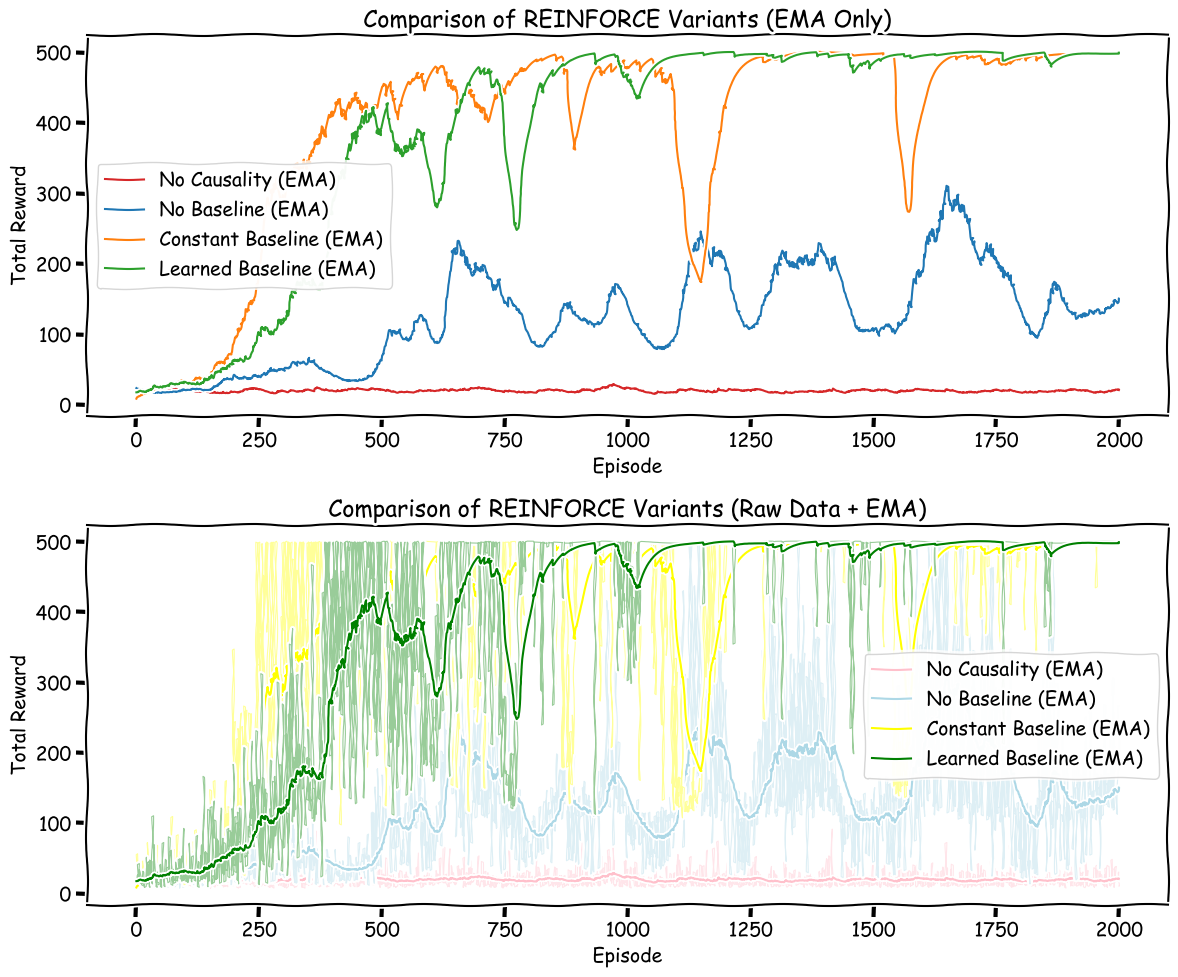

In [33]:
# Plotting Results
window_size = 50

def exponential_moving_average(data, window_size):
    # Implement EMA to smooth the rewards
    alpha = 2 / (window_size + 1)
    ema = np.zeros_like(data)
    ema[0] = data[0]
    
    for i in range(1, len(data)):
        ema[i] = alpha * data[i] + (1 - alpha) * ema[i-1]
    
    return ema

# Plot the results for all 4 methods (Raw data + EMA)
methods = [
    (rewards_no_causality, "No Causality", "tab:red"),
    (rewards_no_baseline, "No Baseline", "tab:blue"),
    (rewards_constant_baseline, "Constant Baseline", "tab:orange"),
    (rewards_with_baseline, "Learned Baseline", "tab:green")
]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

ax1.set_title("Comparison of REINFORCE Variants (EMA Only)")
for rewards, label, color in methods:
    ema = exponential_moving_average(np.array(rewards), window_size)
    ax1.plot(ema, color=color, linewidth=1.5, label=f'{label} (EMA)')
ax1.set_xlabel("Episode")
ax1.set_ylabel("Total Reward")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_title("Comparison of REINFORCE Variants (Raw Data + EMA)")
raw_colors = ['pink', 'lightblue', 'yellow', 'green']
for i, (rewards, label, _) in enumerate(methods):
    ema = exponential_moving_average(np.array(rewards), window_size)
    ax2.plot(rewards, color=raw_colors[i], linewidth=0.8, alpha=0.4)
    ax2.plot(ema, color=raw_colors[i], linewidth=1.5, label=f'{label} (EMA)')
ax2.set_xlabel("Episode")
ax2.set_ylabel("Total Reward")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [34]:
# Calculate and print statistics for all 4 methods
results_stats = [
    ("No Causality", rewards_no_causality),
    ("No Baseline", rewards_no_baseline),
    ("Constant Baseline", rewards_constant_baseline),
    ("Learned Baseline", rewards_with_baseline)
]

for name, rewards in results_stats:
    mean_reward = np.mean(rewards)
    std_reward = np.std(rewards)
    print(f"{name}: mean_reward = {mean_reward:.1f} +/- {std_reward:.1f}")

No Causality: mean_reward = 20.4 +/- 10.7
No Baseline: mean_reward = 126.8 +/- 100.8
Constant Baseline: mean_reward = 403.6 +/- 160.7
Learned Baseline: mean_reward = 393.4 +/- 170.5


**Question:**

Based on the results, how does REINFORCE with a baseline compare to REINFORCE without a baseline in terms of performance?

**Answer:**

REINFORCE with a baseline performs much better than REINFORCE without a baseline and without any baseline the agent gets a modest reward and the results are very unstable with high variance that is meaning the performance jumps around a lot from episode to episode and when we add a baseline the average reward becomes much higher and the learning becomes more stable overall and both the constant baseline and the learned baseline reach far better performance than having no baseline at all so the baseline helps by centering the returns and leading to much better and more consistent learning

**Question:**

Based on the results, how does REINFORCE with a constant baseline compare to REINFORCE with a learned baseline in terms of performance?

**Answer:**

constant baseline and learned baseline perform very similarly in terms of final results and the average rewards are close to each other and the variance is also comparable that is meaning there is no meaningful difference between them in this experiment so learned baseline is more sophisticated and adapts to each state but it does not actually outperform the simple constant baseline here and both methods successfully reduce variance and help the agent reach high scores but the extra complexity of learning a value function did not provide a clear advantage in the CartPole environment

**Question:**

Based on the results, how does REINFORCE without causality trick compare to REINFORCE with causality trick in terms of performance?


**Answer:**

REINFORCE with the causality trick is dramatically better than REINFORCE without it and without causality the agent gets a very poor reward and barely learns at all so with causality the average reward becomes much higher and showing a massive improvement and the reason for this big difference is that without causality every action in an episode gets the same total return as feedback so good and bad actions are treated the same so it confuses the learning process so the causality trick fixes this by giving each action credit only for the rewards that came after it which creates a much cleaner learning signal


**Question:**

Explain how variance affects policy gradient methods, particularly in the context of estimating gradients from sampled trajectories.

**Answer:**

variance in policy gradient methods means that the gradient estimates we compute from different episodes can be very different from each other and from the true gradient we actually want, since we estimate the gradient by sampling a few trajectories rather than seeing all possible ones high variance makes these estimates noisy and unreliable and when variance is high then the updates to the policy can push it in inconsistent directions and sometimes making it better and sometimes making it worse almost randomly so this leads to slow learning because the policy keeps fluctuating instead of steadily improving and in some cases it might not learn at all and the problem comes from the fact that rewards in reinforcement learning are naturally random and small changes in which actions the agent takes can lead to very different total rewards that making it hard to tell which actions were actually good and baselines and causality tricks reduce this variance by removing sources of noise which makes the gradient estimates more stable and helps the policy improve more smoothly and quickly

# Simulation

In [44]:
# Record the simulation using the optimal policy no baseline
record_simulation(gym.make("CartPole-v1", render_mode='rgb_array'), policy_net_causality, "Video_CartPole_no_baseline")

In [45]:
# Record the simulation using the policy trained without causality trick
record_simulation(gym.make("CartPole-v1", render_mode='rgb_array'), policy_net_no_causality, "Video_CartPole_no_causality")

In [46]:
# Record the simulation using the policy trained with constant baseline
record_simulation(gym.make("CartPole-v1", render_mode='rgb_array'), policy_net_const_baseline, "Video_CartPole_constant_baseline")

In [47]:
# Record the simulation using the optimal policy with baseline
record_simulation(gym.make("CartPole-v1", render_mode='rgb_array'), policy_net_learned_baseline, "Video_CartPole_with_baseline")

**Question:**

According to the simulations, how does each algorithm perform on the task after the training?

**Answer:**

policy without causality fails quickly and cannot balance the pole at all

policy with causality but no baseline keeps the pole up for a while but is shaky and unstable

policies with baselines, both constant and learned, perform the best and balancing the pole smoothly and steadily for a long time with controlled movements

overall, adding a baseline makes the biggest visible difference in how well the agent performs in the simulation